# AI Coach - Unrefined Approach (Baseline ML Model)

This notebook documents the **first machine learning approach** attempted for the AI Squat Coach. It serves as a baseline to demonstrate the common pitfalls of a naive implementation and highlights why the more refined approach was necessary.



In [1]:
%pip -q install --upgrade pip
%pip -q install -r requirements.txt || true

import os
import sys
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2 as cv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path
import joblib
from collections import deque
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import kagglehub
import subprocess

from ai_coach.pose import PoseEstimator, compute_basic_angles
from ai_coach.features import extract_feature_vector, FEATURE_ORDER
from ai_coach.per_rep_features import RepAggregate, SQUAT_REP_FEATURES
from ai_coach.exercises import SquatAdvisor, SimpleRepCounter

VIDEO_EXTS = {'.mp4', '.avi', '.mov', '.mkv'}
print("Project modules imported.")


Project modules imported.


In [3]:
DATASET_ID = "hasyimabdillah/workoutfitness-video"
kaggle_path = kagglehub.dataset_download(DATASET_ID, )
print(f"Kaggle dataset ('{DATASET_ID}') downloaded to: {kaggle_path}")


Kaggle dataset ('hasyimabdillah/workoutfitness-video') downloaded to: /Users/user/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5


### 1. Data Extraction and Old Auto-Labeling



In [ ]:
UNREFINED_KNEE_ANGLE_MIN = 65.0   # Stricter: requires a very deep squat
UNREFINED_KNEE_ANGLE_MAX = 110.0  # Stricter: narrower band for "good" depth
UNREFINED_MAX_TORSO_LEAN = 45.0   # Stricter: less tolerance for forward lean
UNREFINED_MIN_KNEE_VALGUS = 0.9   # Stricter: less tolerance for knee collapse

def unrefined_auto_label_rep(rep_vector_dict: dict) -> str:
    """
    Labels a rep using the old, stricter, unrefined logic.
    """
    depth = min(rep_vector_dict["min_left_knee"], rep_vector_dict["min_right_knee"])
    
    if depth > UNREFINED_KNEE_ANGLE_MAX: return "too_high"
    if depth < UNREFINED_KNEE_ANGLE_MIN: return "too_low"
    if rep_vector_dict["max_torso_lean"] > UNREFINED_MAX_TORSO_LEAN: return "bad_posture"
    if rep_vector_dict["min_knee_valgus"] < UNREFINED_MIN_KNEE_VALGUS: return "bad_posture"
    
    return "good"
kaggle_videos = [p for p in Path(kaggle_path).rglob('*') if 'squat' in p.name.lower() and p.suffix.lower() in VIDEO_EXTS]
youtube_videos = [p for p in Path("data/youtube_videos").rglob('*') if p.suffix.lower() in VIDEO_EXTS]
all_videos = kaggle_videos + youtube_videos
print(f"Found {len(all_videos)} videos to process.")

rows = []
pose_estimator = PoseEstimator()

for video_path in tqdm(all_videos, desc="Processing Videos"):
    cap = cv.VideoCapture(str(video_path))
    if not cap.isOpened(): continue
        
    rep_counter = SimpleRepCounter()
    rep_agg = RepAggregate()
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        
        results, _ = pose_estimator.process(frame)
        if not results or not results.pose_landmarks: continue
            
        landmarks = results.pose_landmarks.landmark
        angles = compute_basic_angles(landmarks)
        
        prev_reps = rep_counter.reps
        rep_counter.update(angles)
        rep_agg.update(angles, landmarks)

        if rep_counter.reps > prev_reps:
            feature_vector = rep_agg.to_feature_vector()
            if feature_vector is not None:
                row_dict = {name: val for name, val in zip(SQUAT_REP_FEATURES, feature_vector)}
                row_dict['label'] = unrefined_auto_label_rep(row_dict)
                rows.append(row_dict)
            rep_agg = RepAggregate()
            
    cap.release()
pose_estimator.close()

unrefined_rep_df = pd.DataFrame(rows)
print(f"\nSuccessfully extracted and labeled {len(unrefined_rep_df)} squat repetitions using the unrefined method.")
print("Unrefined Label Distribution:")
print(unrefined_rep_df['label'].value_counts())


Found 134 videos to process.


I0000 00:00:1756143838.215199  116419 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1


Processing Videos:   0%|          | 0/134 [00:00<?, ?it/s]

W0000 00:00:1756143838.432655  349094 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1756143838.452733  349098 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Successfully extracted and labeled 774 squat repetitions using the unrefined method.
Unrefined Label Distribution:
label
too_low        526
bad_posture    212
good            36
Name: count, dtype: int64


### 2. Model Training  & Basic Evaluation




Original training set size: 541
Balancing by undersampling to 25 samples per class.
New balanced training set size: 75

--- Evaluation on Unseen Test Set ---
Accuracy: 0.9399

Classification Report:
               precision    recall  f1-score   support

 bad_posture       0.90      0.97      0.93        64
        good       0.61      1.00      0.76        11
     too_low       1.00      0.92      0.96       158

    accuracy                           0.94       233
   macro avg       0.84      0.96      0.88       233
weighted avg       0.95      0.94      0.94       233



/var/folders/hb/vm3f20gj20b9csml0d9k_wxr0000gn/T/ipykernel_7531/3962443657.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df_balanced = train_df.groupby('label').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
/var/folders/hb/vm3f20gj20b9csml0d9k_wxr0000gn/T/ipykernel_7531/3962443657.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), ax=axes[1], palette='viridis')


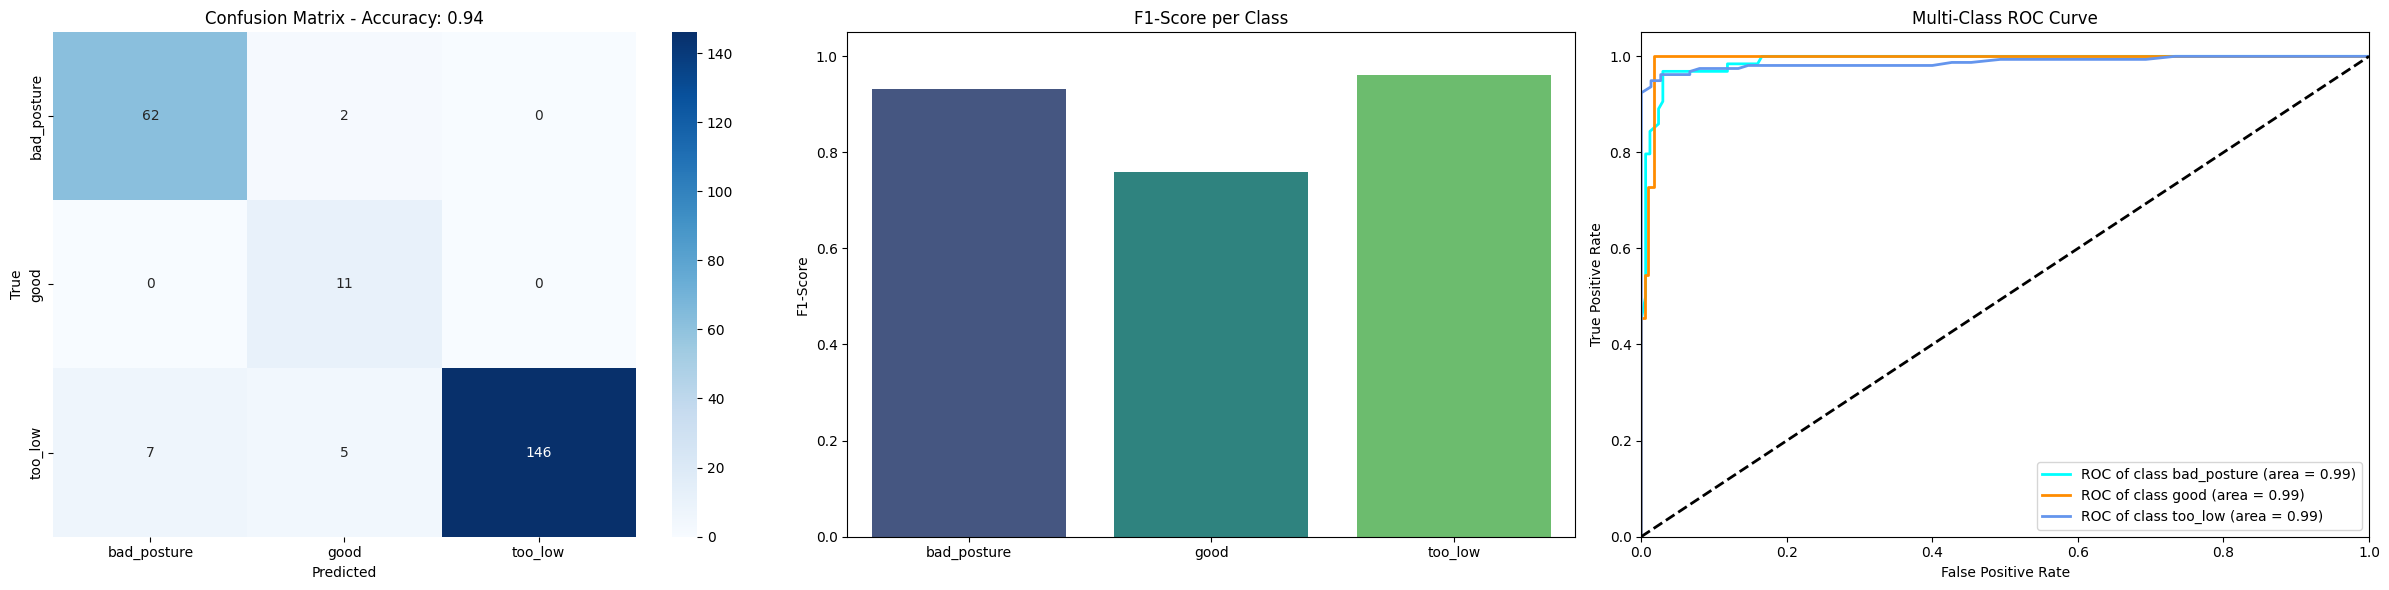

In [ ]:
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

if not unrefined_rep_df.empty and len(unrefined_rep_df['label'].unique()) > 1:
    X_full = unrefined_rep_df[SQUAT_REP_FEATURES].values.astype(np.float32)
    y_full_str = unrefined_rep_df['label'].values
    le = LabelEncoder()
    y_full = le.fit_transform(y_full_str)
    class_names = le.classes_
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
    )
    
    train_df = pd.DataFrame(X_train, columns=SQUAT_REP_FEATURES)
    train_df['label'] = y_train 
    min_count = train_df['label'].value_counts().min()
    
    print(f"Original training set size: {len(train_df)}")
    print(f"Balancing by undersampling to {min_count} samples per class.")
    train_df_balanced = train_df.groupby('label').apply(lambda x: x.sample(min_count, random_state=42)).reset_index(drop=True)
    X_train_balanced = train_df_balanced[SQUAT_REP_FEATURES].values.astype(np.float32)
    
    y_train_balanced = train_df_balanced['label'].values
    
    print(f"New balanced training set size: {len(train_df_balanced)}")
    
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    y_score = clf.predict_proba(X_test)

    print("\n--- Evaluation on Unseen Test Set ---")
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix - Accuracy: {accuracy:.2f}')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    
    f1_scores = {label: report[label]['f1-score'] for label in class_names}
    sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()), ax=axes[1], palette='viridis')
    axes[1].set_title('F1-Score per Class')
    axes[1].set_ylabel('F1-Score')
    axes[1].set_ylim(0, 1.05)
    
    fpr, tpr, roc_auc = dict(), dict(), dict()
    y_test_binarized = label_binarize(y_test, classes=np.arange(len(class_names)))
    
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
    for i, color in zip(range(len(class_names)), colors):
        axes[2].plot(fpr[i], tpr[i], color=color, lw=2,
                     label=f'ROC of class {class_names[i]} (area = {roc_auc[i]:.2f})')
    axes[2].plot([0, 1], [0, 1], 'k--', lw=2)
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('Multi-Class ROC Curve')
    axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

else:
    print("No reps extracted; skipping model training.")


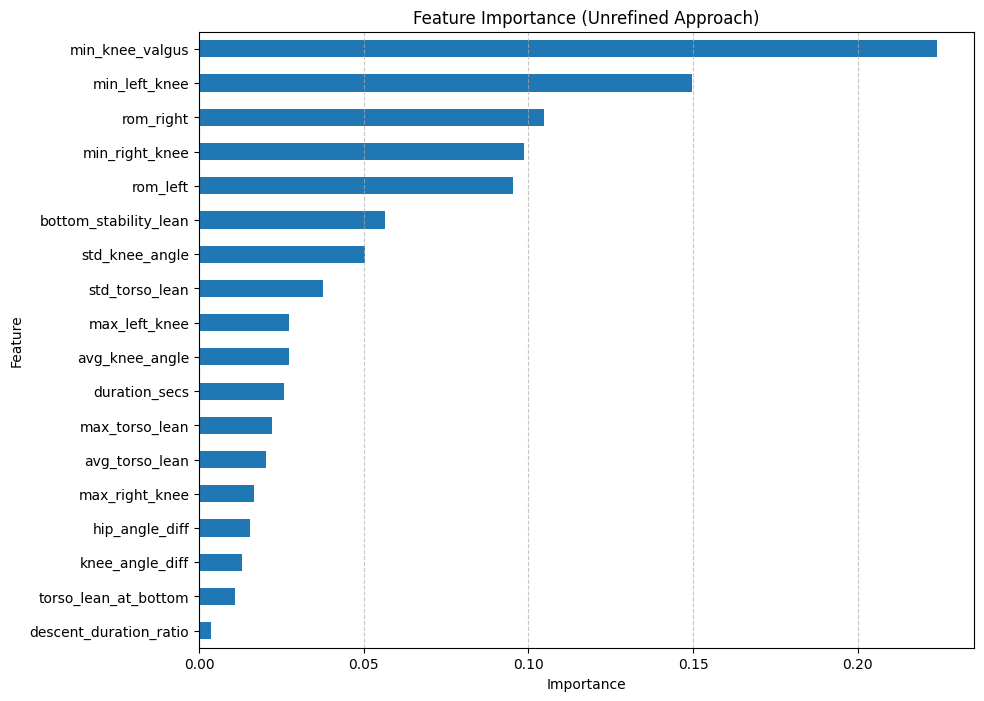

In [ ]:
if 'clf' in locals() and hasattr(clf, 'feature_importances_'):
    importances = pd.Series(clf.feature_importances_, index=SQUAT_REP_FEATURES).sort_values()
    
    plt.figure(figsize=(10, 8))
    importances.plot(kind='barh')
    plt.title('Feature Importance (Unrefined Approach)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    
else:
    print("Classifier 'clf' not found or does not have feature importances. Please run the training cell above.")

